In [1]:
# adapted from https://github.com/DifferentiableUniverseInitiative/Baryonator/blob/main/notebooks/EGD_demo_on_CAMELS.ipynb

In [2]:
# !wget -O snap_020.hdf5 https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG/CV_0/snap_020.hdf5
# !wget -O dm_snap_020.hdf5 https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG_DM/CV_0/snap_020.hdf5

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np

import jax
import jax.lax as lax 
import jax.numpy as jnp

import optax

from tqdm import tqdm
import matplotlib.pyplot as plt
import h5py

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.utils import _initialize_pk
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel

from jaxpm import camels

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [5]:
def gaussian_kernel(kvec, k_smooth):
  """
  Computes a gaussian kernel
  """
  kk = sum(ki**2 for ki in kvec)
  return jnp.exp(-0.5 * kk / k_smooth**2)

## Loading the snapshots

In [6]:
i_snapshot = [-1]
# i_snapshot = None

mesh_shape = [64] * 3
# mesh_shape = [128] * 3

parts_per_dim = mesh_shape[0]
# parts_per_dim = None

# CODE = "IllustrisTNG"
CODE = "SIMBA"

# CV = "CV_0"
CV = "CV_1"

CAMELS = "/pscratch/sd/a/athomsen/flatiron/CAMELS"

hydro_dict = camels.load_CV_snapshots(
    CV,
    mesh_shape[0],
    parts_per_dim=mesh_shape[0],
    i_snapshots=i_snapshot,
    CAMELS=CAMELS,
    CODE=CODE,
    force_h5=True,
)

nbody_dict = camels.load_CV_snapshots(
    CV,
    mesh_shape[0],
    parts_per_dim=mesh_shape[0],
    i_snapshots=i_snapshot,
    CAMELS=CAMELS,
    CODE=CODE,
    return_hydro=False,
    force_h5=True,
)

Creating /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64,i=[-1].h5
No matching catalogs found, returning only the snapshots
Using snapshots ['/pscratch/sd/a/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_1/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 1/1 [00:08<00:00,  8.11s/it]


Found 14533 duplicate gas particle IDs
There are 15868454 (94.58%) gas particles that exist in all snapshots


2025-08-21 07:21:51.749642: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 484.71MiB (rounded to 508255744)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-08-21 07:21:51.749722: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *******_*********************___*****************____********************************************___
E0821 07:21:51.749731  806091 pjrt_stream_executor_client.cc:2939] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 508255584 bytes. [tf-allocator-allocation-error='']
loading snapshots:   0%|          | 0/1 [00:17<?, ?it/s]


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 508255584 bytes.

In [ ]:
# i = 20
# hydro_pos_dm = hydro_dict["dm_poss"][i]
# dmo_pos_dm = nbody_dict["dm_poss"][i]
# hydro_pos_gas = hydro_dict["gas_poss"][i]

hydro_pos_dm = hydro_dict["dm_poss"]
dmo_pos_dm = nbody_dict["dm_poss"]
hydro_pos_gas = hydro_dict["gas_poss"]

cosmo = hydro_dict["cosmo"]
Omega_m = cosmo.Omega_m
Omega_b = cosmo.Omega_b

dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

ax[0].imshow(cic_paint(jnp.zeros(mesh_shape), hydro_pos_dm).sum(axis=0), cmap='gist_stern')
ax[0].set(title="Hydro DM")

ax[1].imshow(cic_paint(jnp.zeros(mesh_shape), dmo_pos_dm).sum(axis=0), cmap='gist_stern')
ax[1].set(title="DMO DM")

ax[2].imshow(cic_paint(jnp.zeros(mesh_shape), hydro_pos_gas).sum(axis=0), cmap='gist_stern')
ax[2].set(title="Hydro Gas")

## Comparing the two simulations

In [9]:
# On the hydro side, let's add both DM and baryons
total_delta_hydro = cic_paint(jnp.zeros(mesh_shape), hydro_pos_dm, weight=dm_mass)
total_delta_hydro = cic_paint(total_delta_hydro, hydro_pos_gas, weight=gas_mass)
total_delta_hydro = total_delta_hydro/total_delta_hydro.mean() - 1

In [10]:
# On the DMO side, we only grab the dark matter
total_delta_dmo = cic_paint(jnp.zeros(mesh_shape), dmo_pos_dm)
total_delta_dmo = total_delta_dmo/total_delta_dmo.mean() - 1

In [11]:
# Let's compute the power spectra
k, pk_hydro = power_spectrum(
      compensate_cic(total_delta_hydro),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

_, pk_dmo = power_spectrum(
      compensate_cic(total_delta_dmo),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)
    
_,xpk =cross_correlation_coefficients(compensate_cic(total_delta_hydro), compensate_cic(total_delta_dmo),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

[None,
 None,
 Text(0.5, 0, '$k$ [$h \\ \\mathrm{Mpc}^{-1}$]'),
 Text(0, 0.5, '$P(k)$')]

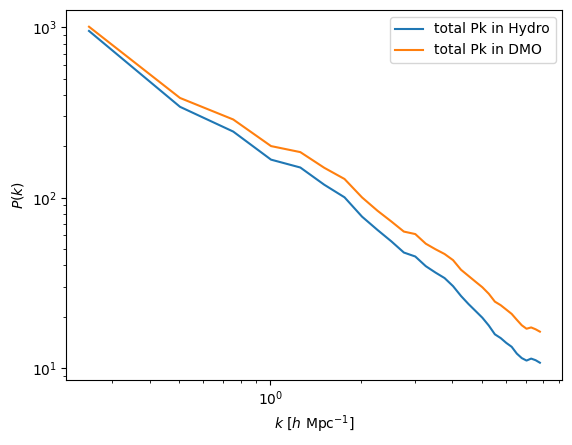

In [12]:
fig, ax = plt.subplots()

ax.plot(k,pk_hydro, label='total Pk in Hydro')
ax.plot(k,pk_dmo, label='total Pk in DMO')
ax.legend()
ax.set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")

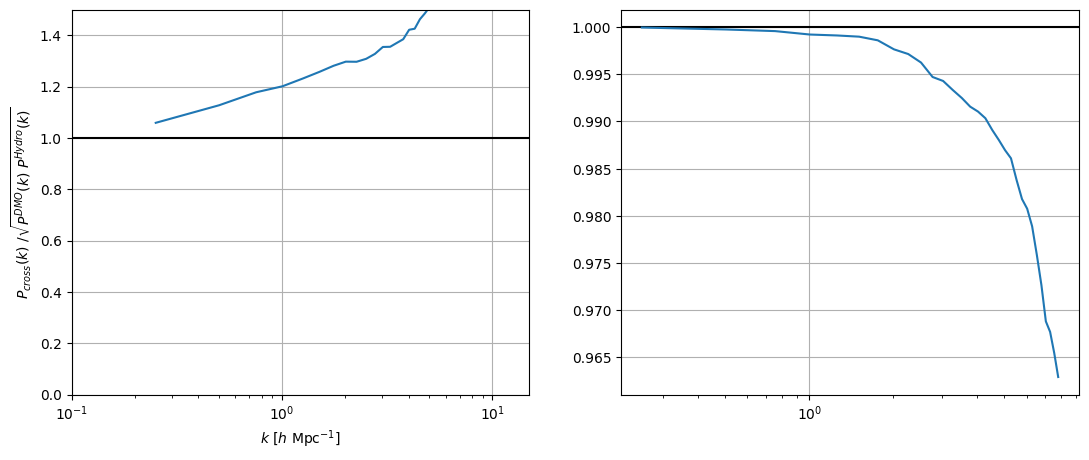

In [13]:
fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_dmo/pk_hydro))   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[0].grid(True)

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk/(jnp.sqrt(pk_dmo)*jnp.sqrt(pk_hydro)))
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[1].grid()

## Implementing vanilla Enthalpy Gradient Descent

Here we first attempt to reproduce the results of [Dai et al. 2018](https://arxiv.org/abs/1804.00671) which introduces a method coined EGD to displace DM particles in a DMO run into tracing the total matter distribution from a full hydro run.

In this work, the authors assume that a fraction $\Omega_b/\Omega_m$ of the particles will be displaced according to this EGD prescription. We are thus going to split our input DM particles into 2 populations, randomly.

In [14]:
inds = jax.random.permutation(jax.random.PRNGKey(42), jnp.arange(0,len(dmo_pos_dm)-1))
split = int(Omega_b/Omega_m*len(dmo_pos_dm))
egd_pos_gas = dmo_pos_dm[inds[:split]]
egd_pos_dm  = dmo_pos_dm[inds[split:]]

egd_rho_dm = cic_paint(jnp.zeros(mesh_shape), egd_pos_dm)

In [15]:
def egd_correction(delta, pos, params):
    """
    Will compute the EGD displacement as a function of density traced by the 
    input particles.
    params contains [amplitude, scale, gamma]
    """
    kvec = fftk(mesh_shape)
    alpha, kl, gamma = params

    # Compute a temperature-like map from density contrast
    T = (delta+1)**gamma
    
    # Apply FFT to apply filtering
    T_k = jnp.fft.rfftn(T)
    filtered_T_k = gaussian_kernel(kvec, kl) * T_k # This applies a Gaussian smoothing

    # Compute derivatives of this filtered T-like field at the position of particles
    dpos_egd = jnp.stack([cic_read(jnp.fft.irfftn(gradient_kernel(kvec, i)*filtered_T_k), pos) 
                      for i in range(3)],axis=-1)
    
    # Apply overal scaling of these displacements
    dpos_egd = - alpha * dpos_egd
   
    return dpos_egd

Now let's try to optimize parameters of this model

In [16]:
learning_rate = 0.1
optimizer = optax.adam(learning_rate)

In [17]:
# I define my loss function
@jax.jit
def loss_fn(params):
  egdized_pos_gas = egd_pos_gas + egd_correction(total_delta_dmo, egd_pos_gas, params)

  # Add the gas that we have moved to the dm that stayed where it was
  delta = cic_paint(egd_rho_dm, egdized_pos_gas)
  delta = delta/delta.mean() - 1.

  # Compute the PS of everybody
  k,pk=power_spectrum(compensate_cic(delta),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)
  
  # Some weighting function of the pk, following Biwei's strategy
  inds = k < 10.
  return jnp.sum(((pk/pk_hydro -1))[inds]**2,axis=-1)
  # return jnp.sum( (delta-total_delta_hydro)**2)

# And the optimizer update function (this is common optax boiler plate)
@jax.jit
def update(params, opt_state):
    """Single SGD update step."""
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, new_opt_state

In [18]:
# Let's initialize parameters and optimizer
params = [0.5, 1.4, 0.4] # amplitude, scale, gamma
opt_state = optimizer.init(params)
losses = []

In [32]:
# for step in tqdm(range(3000)):
#   l, params, opt_state = update(params, opt_state)
#   losses.append(l)

In [33]:
# plt.plot(losses[200:])
# params

In [34]:
params = [
    np.array(0.79741, dtype=np.float32),
    np.array(7.9030437, dtype=np.float32),
    np.array(0.51323, dtype=np.float32)
]

In [35]:
# Let's look at the result
# On the DMO side, we only grab the dark matter
total_rho_egd = cic_paint(egd_rho_dm, egd_pos_gas + egd_correction(total_delta_dmo, egd_pos_gas, params))
total_delta_egd = total_rho_egd/total_rho_egd.mean() - 1

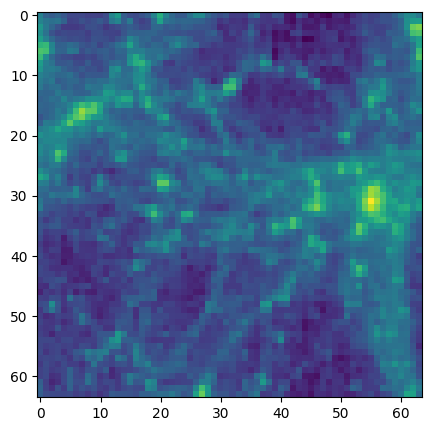

In [36]:
fig, ax = plt.subplots(figsize=(5,5))

ax.imshow(jnp.log(total_rho_egd.sum(axis=0)))

[Text(0.5, 1.0, 'DMO+EGD')]

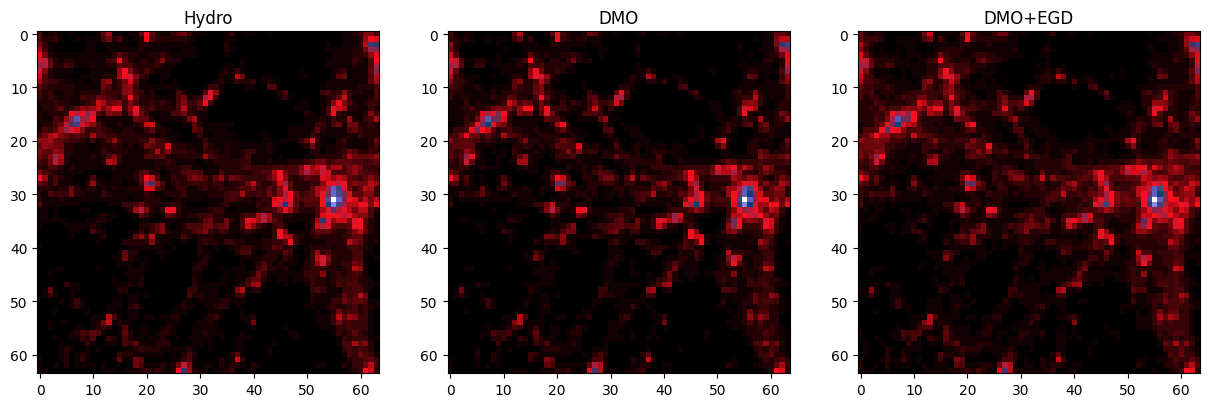

In [23]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

ax[0].imshow(total_delta_hydro.sum(axis=0), cmap='gist_stern')
ax[0].set(title="Hydro")

ax[1].imshow(total_delta_dmo.sum(axis=0), cmap='gist_stern')
ax[1].set(title="DMO")

ax[2].imshow(total_delta_egd.sum(axis=0), cmap='gist_stern')
ax[2].set(title="DMO+EGD")

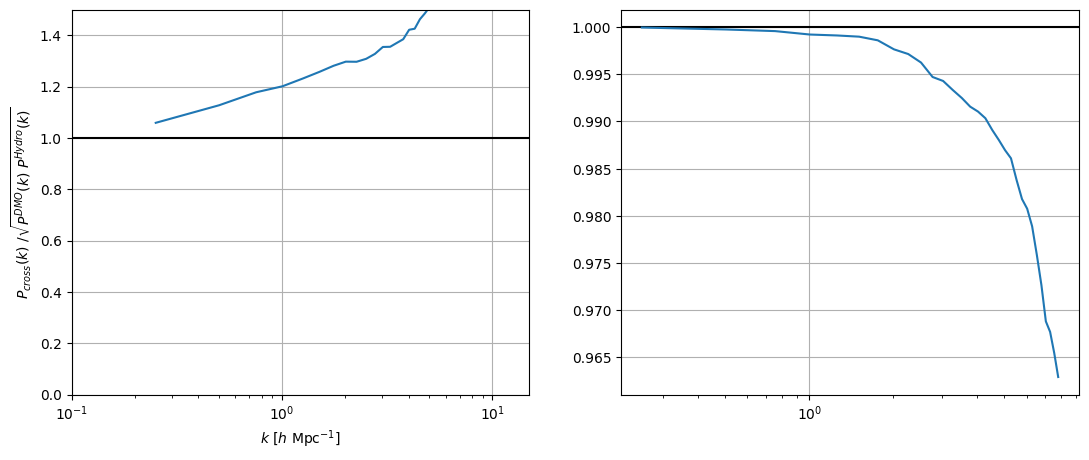

In [24]:
fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_dmo/pk_hydro))   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[0].grid(True)

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk/(jnp.sqrt(pk_dmo)*jnp.sqrt(pk_hydro)))
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[1].grid()

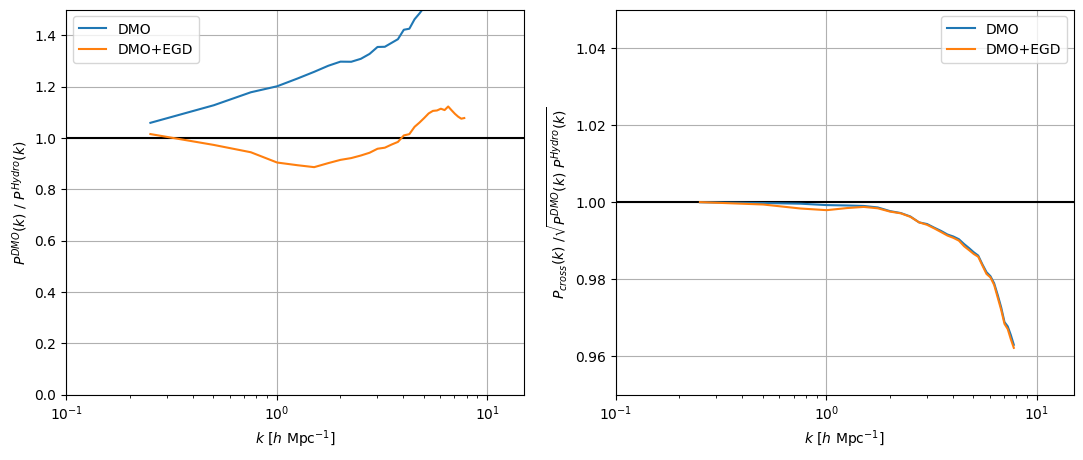

In [25]:
# Now let's compute 2pt stats
_, pk_egd = power_spectrum(
      compensate_cic(total_delta_egd),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

_, xpk_egd = cross_correlation_coefficients(compensate_cic(total_delta_hydro), compensate_cic(total_delta_egd),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_dmo/pk_hydro), label='DMO')   
ax[0].semilogx(k, (pk_egd/pk_hydro), label='DMO+EGD')   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[0].grid(True)
ax[0].legend()

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk/(jnp.sqrt(pk_dmo)*jnp.sqrt(pk_hydro)), label='DMO')
ax[1].semilogx(k, xpk_egd/(jnp.sqrt(pk_egd)*jnp.sqrt(pk_hydro)), label='DMO+EGD')
ax[1].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    xlim=(0.1, 15),
    ylim=(0.95, 1.05),
)
ax[1].grid()
ax[1].legend()

In [26]:
egdized_pos_gas = egd_pos_gas + egd_correction(total_delta_dmo, egd_pos_gas, params)
delta_egd_gas = cic_paint(jnp.zeros(mesh_shape), egdized_pos_gas)
delta_egd_gas = delta_egd_gas/delta_egd_gas.mean() - 1.

# Compute the PS of everybody
k, pk_egd_gas = power_spectrum(
    compensate_cic(delta_egd_gas),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

delta_gas = cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"])
delta_gas = delta_gas/delta_gas.mean() - 1.

# Compute the PS of everybody
k, pk_gas = power_spectrum(
    compensate_cic(delta_gas),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)


[None,
 None,
 Text(0.5, 0, '$k$ [$h \\ \\mathrm{Mpc}^{-1}$]'),
 Text(0, 0.5, '$P(k)$')]

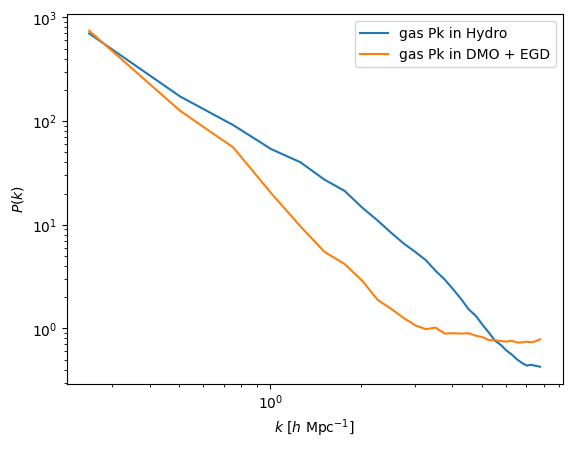

In [27]:
fig, ax = plt.subplots()

ax.plot(k, pk_gas, label='gas Pk in Hydro')
ax.plot(k, pk_egd_gas, label='gas Pk in DMO + EGD')
ax.legend()
ax.set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")

In [28]:
egdized_pos_gas.shape

(42816, 3)

In [29]:
stop

NameError: name 'stop' is not defined

# validation

In [ ]:
hydro_dict_vali = camels.load_CV_snapshots(
    "CV_1",
    mesh_shape[0],
    # parts_per_dim=mesh_shape[0],
    parts_per_dim=None,
    # i_snapshots=None,
    i_snapshots=i_snapshot,
    CAMELS=CAMELS,
    CODE=CODE,
    force_h5=True,
)

nbody_dict_vali = camels.load_CV_snapshots(
    "CV_1",
    mesh_shape[0],
    # parts_per_dim=mesh_shape[0],
    parts_per_dim=None,
    # i_snapshots=None,
    i_snapshots=i_snapshot,
    CAMELS=CAMELS,
    CODE=CODE,
    return_hydro=False,
    force_h5=True,
)

In [ ]:
hydro_pos_dm = hydro_dict_vali["dm_poss"]
dmo_pos_dm = nbody_dict_vali["dm_poss"]
hydro_pos_gas = hydro_dict_vali["gas_poss"]

cosmo = hydro_dict_vali["cosmo"]
Omega_m = cosmo.Omega_m
Omega_b = cosmo.Omega_b

dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

In [ ]:
# On the hydro side, let's add both DM and baryons
total_delta_hydro = cic_paint(jnp.zeros(mesh_shape), hydro_pos_dm, weight=dm_mass)
total_delta_hydro = cic_paint(total_delta_hydro, hydro_pos_gas, weight=gas_mass)
total_delta_hydro = total_delta_hydro/total_delta_hydro.mean() - 1

In [ ]:
# On the DMO side, we only grab the dark matter
total_delta_dmo = cic_paint(jnp.zeros(mesh_shape), dmo_pos_dm)
total_delta_dmo = total_delta_dmo/total_delta_dmo.mean() - 1

In [ ]:
# Let's look at the result
# On the DMO side, we only grab the dark matter
total_delta_egd = cic_paint(egd_rho_dm, egd_pos_gas + egd_correction(total_delta_dmo, egd_pos_gas, params))
total_delta_egd = total_delta_egd/total_delta_egd.mean() - 1

In [ ]:
k, pk_hydro = power_spectrum(
      compensate_cic(total_delta_hydro),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

_, pk_dmo = power_spectrum(
      compensate_cic(total_delta_dmo),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)
    
_, xpk =cross_correlation_coefficients(compensate_cic(total_delta_hydro), compensate_cic(total_delta_dmo),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

In [ ]:
_, pk_egd = power_spectrum(
      compensate_cic(total_delta_egd),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

_, xpk_egd = cross_correlation_coefficients(compensate_cic(total_delta_hydro), compensate_cic(total_delta_egd),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_dmo/pk_hydro), label='DMO')   
ax[0].semilogx(k, (pk_egd/pk_hydro), label='DMO+EGD')   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[0].grid(True)
ax[0].legend()

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk/(jnp.sqrt(pk_dmo)*jnp.sqrt(pk_hydro)), label='DMO')
ax[1].semilogx(k, xpk_egd/(jnp.sqrt(pk_egd)*jnp.sqrt(pk_hydro)), label='DMO+EGD')
ax[1].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    xlim=(0.1, 15),
    ylim=(0.95, 1.05),
)
ax[1].grid()
ax[1].legend()